Saving 1.jpg to 1.jpg
Saving 2.jpg to 2.jpg
Saving 3.jpg to 3.jpg
Saving 4.jpg to 4.jpg
Saving 5.jpg to 5.jpg
Saving 6.jpg to 6.jpg
Знайдено фото: 6
/content/pano/1.jpg
/content/pano/2.jpg
/content/pano/3.jpg
/content/pano/4.jpg
/content/pano/5.jpg
/content/pano/6.jpg
Готово: /content/result/panorama.jpg


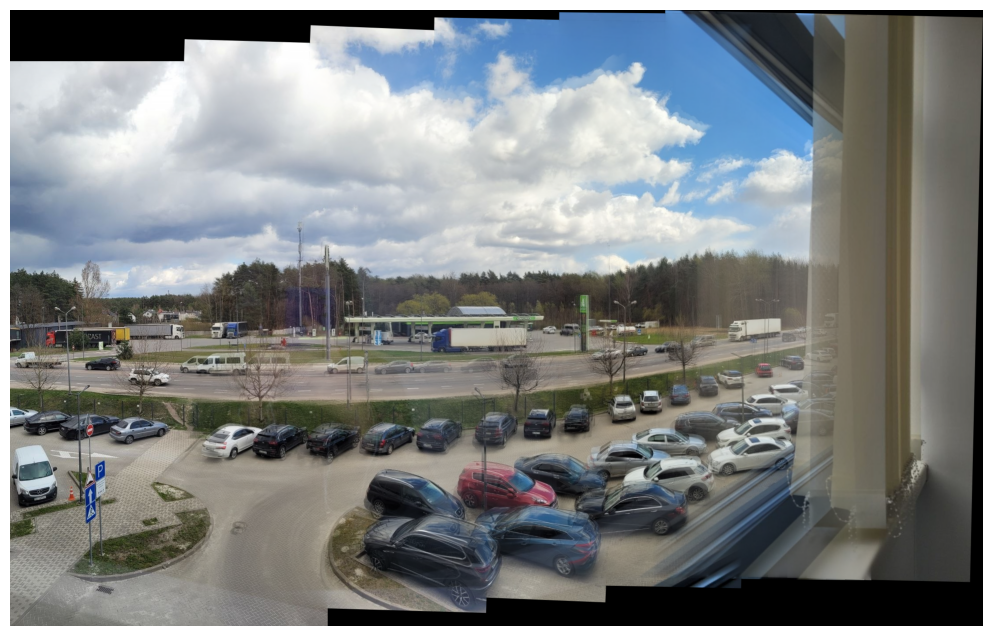

In [2]:
import cv2
import glob
import os
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt

# 1. Завантаж фото
uploaded = files.upload()

# 2. Папка для фото
IMG_DIR = "/content/pano"
os.makedirs(IMG_DIR, exist_ok=True)

for fname in uploaded.keys():
    os.rename(fname, os.path.join(IMG_DIR, fname))

def read_images(folder_glob):
    paths = sorted(glob.glob(folder_glob))
    imgs = []

    for p in paths:
        img = cv2.imread(p)
        if img is not None:
            imgs.append(img)

    return imgs, paths

def detect_and_match(img1, img2, nfeatures=4000):
    orb = cv2.ORB_create(nfeatures=nfeatures)

    k1, d1 = orb.detectAndCompute(img1, None)
    k2, d2 = orb.detectAndCompute(img2, None)

    if d1 is None or d2 is None:
        return np.empty((0, 2), dtype=np.float32), np.empty((0, 2), dtype=np.float32)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.knnMatch(d1, d2, k=2)

    ok = []
    for pair in matches:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < 0.75 * n.distance:
            ok.append(m)

    if len(ok) < 8:
        return np.empty((0, 2), dtype=np.float32), np.empty((0, 2), dtype=np.float32)

    pts1 = np.float32([k1[m.queryIdx].pt for m in ok])
    pts2 = np.float32([k2[m.trainIdx].pt for m in ok])

    return pts1, pts2

def estimate_rigid_ls(A, B):
    if len(A) < 2:
        return np.eye(2, dtype=np.float64), np.zeros(2, dtype=np.float64)

    A = A.astype(np.float64)
    B = B.astype(np.float64)

    ca = A.mean(axis=0)
    cb = B.mean(axis=0)

    AA = A - ca
    BB = B - cb

    H = AA.T @ BB
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[1, :] *= -1
        R = Vt.T @ U.T

    t = cb - ca @ R.T
    return R, t

def apply_rigid(points, R, t):
    return points @ R.T + t

def ransac_rigid(A, B, iters=2000, thresh=3.5):
    n = len(A)
    if n < 2:
        return np.eye(2), np.zeros(2), np.zeros((n,), dtype=bool)

    rng = np.random.default_rng(0)

    best_count = 0
    best_inliers = None
    best_R = np.eye(2)
    best_t = np.zeros(2)

    for _ in range(iters):
        idx = rng.choice(n, size=2, replace=False)

        R, t = estimate_rigid_ls(A[idx], B[idx])
        pred = apply_rigid(A, R, t)
        err = np.linalg.norm(pred - B, axis=1)
        inliers = err < thresh

        count = int(inliers.sum())
        if count > best_count:
            best_count = count
            best_inliers = inliers
            best_R = R
            best_t = t

            if best_count > 0.85 * n:
                break

    if best_inliers is None or best_count < 2:
        return np.eye(2), np.zeros(2), np.zeros((n,), dtype=bool)

    best_R, best_t = estimate_rigid_ls(A[best_inliers], B[best_inliers])
    return best_R, best_t, best_inliers

def rigid_to_affine2x3(R, t):
    M = np.zeros((2, 3), dtype=np.float64)
    M[:, :2] = R
    M[:, 2] = t
    return M

def affine2x3_compose(M2, M1):
    A1 = M1[:, :2]
    t1 = M1[:, 2]

    A2 = M2[:, :2]
    t2 = M2[:, 2]

    A = A2 @ A1
    t = A2 @ t1 + t2

    M = np.zeros((2, 3), dtype=np.float64)
    M[:, :2] = A
    M[:, 2] = t
    return M

def transform_points(M, pts):
    return pts @ M[:, :2].T + M[:, 2]

def warp_and_blend(images, transforms):
    corners_all = []

    for img, M in zip(images, transforms):
        h, w = img.shape[:2]
        corners = np.array([
            [0, 0],
            [w, 0],
            [w, h],
            [0, h]
        ], dtype=np.float64)

        tc = transform_points(M, corners)
        corners_all.append(tc)

    corners_all = np.vstack(corners_all)

    min_xy = np.floor(corners_all.min(axis=0)).astype(int)
    max_xy = np.ceil(corners_all.max(axis=0)).astype(int)

    shift = -min_xy
    pano_w = int(max_xy[0] - min_xy[0])
    pano_h = int(max_xy[1] - min_xy[1])

    acc = np.zeros((pano_h, pano_w, 3), dtype=np.float32)
    wacc = np.zeros((pano_h, pano_w), dtype=np.float32)

    for img, M in zip(images, transforms):
        M_shifted = M.copy()
        M_shifted[:, 2] += shift

        warped = cv2.warpAffine(
            img,
            M_shifted,
            (pano_w, pano_h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT
        )

        mask = (warped.sum(axis=2) > 0).astype(np.uint8) * 255

        dist = cv2.distanceTransform(mask, cv2.DIST_L2, 3)
        if dist.max() > 0:
            dist = dist / (dist.max() + 1e-6)

        weight = dist.astype(np.float32)

        acc += warped.astype(np.float32) * weight[..., None]
        wacc += weight

    wacc = np.maximum(wacc, 1e-6)
    pano = (acc / wacc[..., None]).clip(0, 255).astype(np.uint8)

    return pano

def build_panorama(images):
    transforms = [
        np.array([
            [1.0, 0.0, 0.0],
            [0.0, 1.0, 0.0]
        ], dtype=np.float64)
    ]

    for i in range(1, len(images)):
        prev_gray = cv2.cvtColor(images[i - 1], cv2.COLOR_BGR2GRAY)
        cur_gray = cv2.cvtColor(images[i], cv2.COLOR_BGR2GRAY)

        pts_cur, pts_prev = detect_and_match(cur_gray, prev_gray)

        if len(pts_cur) < 8:
            raise RuntimeError(f"Замало співпадінь між кадрами {i-1} та {i}: {len(pts_cur)}")

        R, t, inliers = ransac_rigid(pts_cur, pts_prev, iters=2000, thresh=3.5)

        if inliers.sum() < 6:
            raise RuntimeError(f"RANSAC дав замало інлайнерів між кадрами {i-1} та {i}: {int(inliers.sum())}")

        M_cur_to_prev = rigid_to_affine2x3(R, t)
        M_prev_to_global = transforms[i - 1]
        M_cur_to_global = affine2x3_compose(M_prev_to_global, M_cur_to_prev)

        transforms.append(M_cur_to_global)

    pano = warp_and_blend(images, transforms)
    return pano

folder = os.path.join(IMG_DIR, "*.*")
images, paths = read_images(folder)

print("Знайдено фото:", len(paths))
for p in paths:
    print(p)

if len(images) < 2:
    raise ValueError("Треба мінімум 2 фото")

pano = build_panorama(images)

out_dir = "/content/result"
os.makedirs(out_dir, exist_ok=True)

out_path = os.path.join(out_dir, "panorama.jpg")
cv2.imwrite(out_path, pano)

print("Готово:", out_path)

pano_rgb = cv2.cvtColor(pano, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(18, 8))
plt.imshow(pano_rgb)
plt.axis("off")
plt.show()